In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

## data

In [ ]:
# DATA_DIR='../data_processed'
# # groups=[   
# #     'london_2306', "london_2309", "london_2312","london_2403",'london_2406',
# #     'paris_2306', "paris_2309", "paris_2312","paris_2403","paris_2406"
# # ]
# groups=[   
#     'london_2306', "london_2312",'london_2406',
#     'paris_2306',"paris_2312","paris_2406"
# ]

# list_df=[]
# for i,group in enumerate(groups):
#     df_dir=os.path.join(DATA_DIR, group)
#     path_df=os.path.join(df_dir, [f for f in os.listdir(df_dir) if f.startswith("listings_processed")][0])
#     print(path_df)

#     df=pd.read_csv(path_df)
#     print(f"{i}-{group}:{df.shape}\n")
   
#     # check:
#     # print(group)
#     # print(df.in_paris.value_counts())
#     # print(df.time.value_counts(),"\n")
#     list_df.append(df)

# df_pre=pd.concat(list_df, axis=0)
# print(df_pre.shape)
# print(df_pre[['in_paris','time']].value_counts(dropna=False))

../data_processed\london_2306\listings_processed_london_2306.csv
0-london_2306:(42356, 91)

../data_processed\london_2312\listings_processed_london_2312.csv
1-london_2312:(43172, 90)

../data_processed\london_2406\listings_processed_london_2406_49856.csv
2-london_2406:(49856, 92)

../data_processed\paris_2306\listings_processed_paris_2306.csv


C:\Users\yeliu\AppData\Local\Temp\ipykernel_33172\2304432944.py:18: DtypeWarning: Columns (59,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


3-paris_2306:(32901, 91)

../data_processed\paris_2312\listings_processed_paris_2312.csv
4-paris_2312:(35829, 92)

../data_processed\paris_2406\listings_processed_paris_2406_62738.csv
5-paris_2406:(62738, 91)

(266852, 93)
in_paris  time
1         2406    62738
0         2406    49856
          2312    43172
          2306    42356
1         2312    35829
          2306    32901
Name: count, dtype: int64


In [2]:
df_all=pd.read_csv("../data_processed\listings_tactics-paris_london-2306_2312_2406.csv")
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_27696\1726051960.py:1: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv("../data_processed\listings_tactics-paris_london-2306_2312_2406.csv")


(266852, 121)


In [5]:
df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)
print(df_all.time.value_counts(dropna=False))
# df_pre['time'] = df_pre['time'].astype(str)
# df_pre.time.value_counts(dropna=False)

object
time
2406    112594
2312     79001
2306     75257
Name: count, dtype: int64


In [ ]:
# 我们要估计：不同时点，Paris 相对于 London 的差异变化

# 重点看：
# pre-period（2309, 2312）系数是否 ≈ 0 → parallel trend
# post（2406）是否显著 → 奥运影响

import pandas as pd

df = df_all.copy()

# 设定 baseline（reference period）
# 2306 作为基准，不进入回归


import statsmodels.formula.api as smf
formula=("booking_rate_l90d ~" 
        "C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price   + C(room_type) + C(instant_bookable) + availability_90+"
        "in_paris * C(time) "
        # "in_paris * in_2024 "
)

# formula=(
#     "booking_rate_l90d ~ "
#     "C(host_identity_verified)  + review_scores_rating + has_rating +"
#     "number_of_reviews_ltm + "
#     "C(host_is_superhost) +"
#     "years_since_host + professional_host + "
#     "host_response_rate +  +C(host_response_time)+"
#     # "has_text + "
#     "lang_en + lang_fr + text_length + "
#     "C(time)*in_paris"
# )

formula='booking_rate_l90d ~ C(time)*in_paris'
model = smf.ols(
    formula,    
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['in_paris']})

print(model.summary())

## 交互项显著,平行趋势不成立!

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                 5.460e+23
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           9.57e-13
Time:                        08:18:22   Log-Likelihood:                 26440.
No. Observations:              266852   AIC:                        -5.287e+04
Df Residuals:                  266846   BIC:                        -5.280e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

d:\miniconda3\envs\airbnb_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '


C(time)[T.2312]:in_paris   -0.020952
C(time)[T.2406]:in_paris   -0.094564
dtype: float64
['2312', '2406']


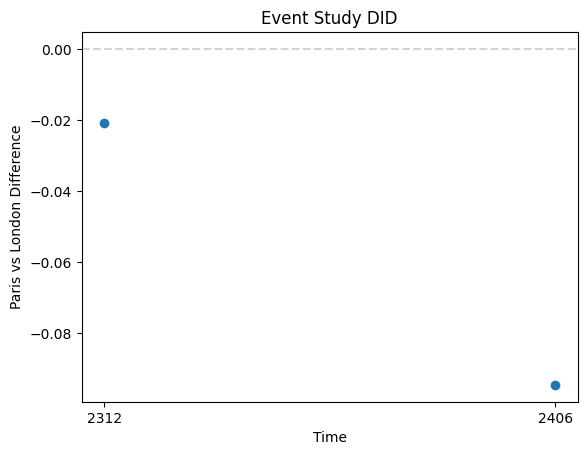

In [13]:
# 检查趋势差异的大小
## 加不加控制变量，差距不大
import matplotlib.pyplot as plt

coefs = model.params.filter(like=':in_paris')
errors = model.bse.filter(like=':in_paris')
# print(coefs)

# times = ['2309', '2312', "2403", '2406']
times=[t for t in df.time.unique() if t!="2306"]
# print(times)

plt.errorbar(times, coefs, yerr=1.96*errors, fmt='o')
plt.axhline(0,linestyle='--', color="lightgray")
plt.title('Event Study DID')
plt.xlabel('Time')
plt.ylabel('Paris vs London Difference')
plt.show()

## 应该尽可能靠近0，且差距不显著。parallel显然不成立！

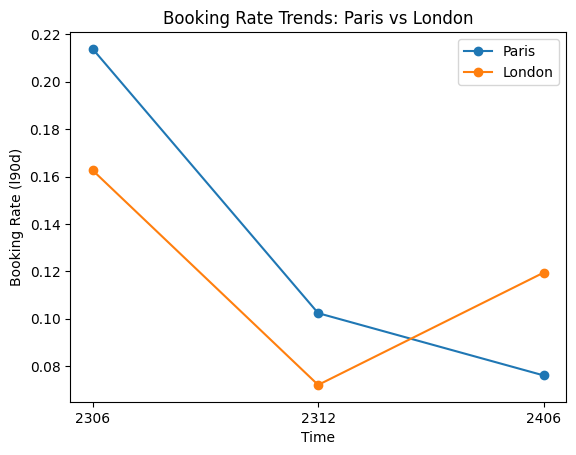

In [14]:
# 检查两地预订率的变化,每个时间点的垂直距离代表差异,对应线之间斜率差代表趋势差异,对应交互项

import matplotlib.pyplot as plt

avg = df.groupby(['time', 'in_paris'])['booking_rate_l90d'].mean().reset_index()

# pivot 成两列
pivot = avg.pivot(index='time', columns='in_paris', values='booking_rate_l90d')

plt.plot(pivot.index, pivot[1], marker='o', label='Paris')
plt.plot(pivot.index, pivot[0], marker='o', label='London')

# plt.axvline('2406', linestyle='--', color='gray')  # treatment time

plt.title('Booking Rate Trends: Paris vs London')
plt.xlabel('Time')
plt.ylabel('Booking Rate (l90d)')
plt.legend()
plt.show()

## trend

In [16]:
print(df_pre.time.value_counts(dropna=False))
df_pre.time.dtype

time
2406    112594
2312     79001
2306     75257
Name: count, dtype: int64


dtype('O')

In [ ]:
# in_paris * post : 奥运会对 Paris 的因果影响（DID effect）
# t * in_paris: 允许 Paris 有一条“自己的趋势线”，不和lonodn保持parallel
# C(time) 控制季节，宏观变化


# C(time)：控制整体时间变化（季节、宏观要素）
# t*in_paris：显示 Paris 和 London 有不同趋势.构建连续变量t，代表时间发展，（已知paris和london发展趋势不平行），通过t:in_paris的交互项提取处代表paris/london的之间的trend heterogeneity
## 负值说明了每往后一个时间点，Paris 相对 London 多下降 0.0042（下降更快）
# 控制city trend之后，in_paris:post识别奥运的额外冲击

# df=df_pre[df_pre['time'].isin([2306, 2312,2406])].copy()
# print(df.shape)


# df['t'] = df['time'].map({'2306':0, '2309':1, '2312':2, '2403':3,'2406':4})

df['t'] = df['time'].map({'2306':0, "2312":1, '2406':2})#***
df['post']=df['time'].apply(lambda x : 1 if x=='2406' else 0)

print(df[['t','post']].value_counts())
model = smf.ols(
    'booking_rate_l90d ~ in_paris*post + t*in_paris + C(time) ',
    data=df
).fit()
print(model.summary())

t  post
2  1       112594
1  0        79001
0  0        75257
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     2483.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:48:02   Log-Likelihood:                 26440.
No. Observations:              266852   AIC:                        -5.287e+04
Df Residuals:                  266846   BIC:                        -5.280e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

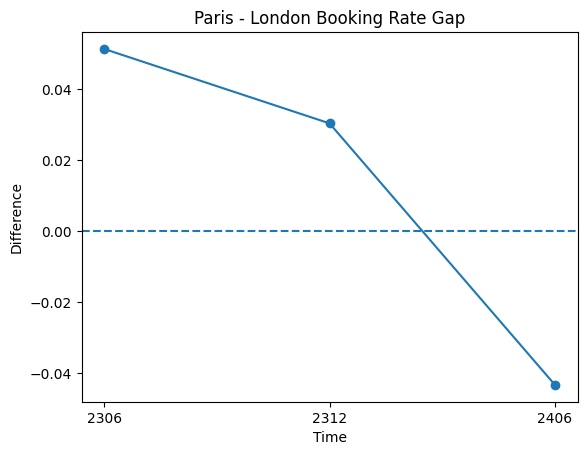

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 计算每个时间点的均值
avg = df.groupby(['time', 'in_paris'])['booking_rate_l90d'].mean().reset_index()

pivot = avg.pivot(index='time', columns='in_paris', values='booking_rate_l90d')

# 计算差值
pivot['gap'] = pivot[1] - pivot[0]

plt.plot(pivot.index, pivot['gap'], marker='o')

plt.axhline(0, linestyle='--')
# plt.axvline('2406', linestyle='--', color='gray')

plt.title('Paris - London Booking Rate Gap')
plt.xlabel('Time')
plt.ylabel('Difference')

plt.show()

In [ ]:
model = smf.ols(
    'booking_rate_l90d ~ t*in_paris + post',
    # "booking_rate_l90d ~ C(time)*in_paris",
    # post不加in_paris因为我们需要观察post整体的效果，来预测paris在post0, 2406的预订率？
    
data=df
).fit()

print(df[['time','in_paris','post']].value_counts(dropna=False))

## 用model预测y
df['pred_actual'] = model.predict(df)


# 如果paris 2406没有发生jo,预订率会怎么变化？
# ✔ in_paris = 1   （它还是 Paris）
# ✔ t × in_paris   （它的趋势）
# ✔ C(time)        （季节性）
# 关掉in_paris × post

df_cf = df.copy()

# 选取2406年in_paris数据，把1改成0，继承london的趋势
# df_cf.loc[(df_cf['time'] == '2406') & (df_cf['in_paris'] == 1), 'post'] = 0
df_cf.loc[(df_cf['time'] == '2406') & (df_cf['in_paris'] == 1), 'in_paris'] = 0

df_cf['pred_cf'] = model.predict(df_cf)


# London actual
london = df[df['in_paris'] == 0]
london_mean = london.groupby('time')['booking_rate_l90d'].mean()

# Paris actual
paris = df[df['in_paris'] == 1]
paris_mean = paris.groupby('time')['booking_rate_l90d'].mean()

# Paris counterfactual（关键）
paris_cf = df_cf[df['in_paris'] == 1]
cf_mean = paris_cf.groupby('time')['pred_cf'].mean()

# show
print("london actual: ",london_mean)
print("paris actual: ",paris_mean)
print("paris_cf",cf_mean)

time  in_paris  post
2406  1         1       62738
      0         1       49856
2312  0         0       43172
2306  0         0       42356
2312  1         0       35829
2306  1         0       32901
Name: count, dtype: int64
london actual:  time
2306    0.162585
2312    0.072095
2406    0.119446
Name: booking_rate_l90d, dtype: float64
paris actual:  time
2306    0.213811
2312    0.102370
2406    0.076108
Name: booking_rate_l90d, dtype: float64
paris_cf time
2306    0.219249
2312    0.092381
2406    0.115857
Name: pred_cf, dtype: float64


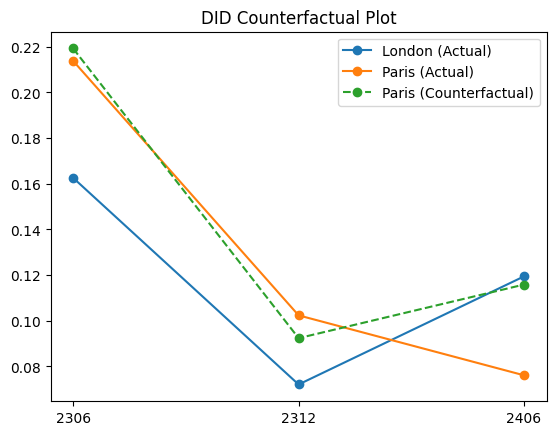

In [99]:
import matplotlib.pyplot as plt

plt.plot(london_mean.index, london_mean, marker='o', label='London (Actual)')
plt.plot(paris_mean.index, paris_mean, marker='o', label='Paris (Actual)')
plt.plot(cf_mean.index, cf_mean, linestyle='--', marker='o', label='Paris (Counterfactual)')

# plt.axvline('2406', linestyle=':', color='gray')

plt.legend()
plt.title('DID Counterfactual Plot')
plt.show()

In [19]:
# 对比：如果平行趋势 OK：标准 DID（用于报告）
df['post'] = (df['time'] == '2406').astype(int)
model_did = smf.ols(
    'booking_rate_l90d ~ in_paris*post + C(time)',
    data=df
).fit()

print(model_did.summary())

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     2464.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:23:03   Log-Likelihood:                 26396.
No. Observations:              266852   AIC:                        -5.278e+04
Df Residuals:                  266846   BIC:                        -5.272e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1678      0.001    1

In [21]:
print(df_pre.time.dtype)

float64
